# Xenium HBC1 · V1002 exploratory niches

Official [10x Xenium FFPE Human Breast Cancer Replicate 1](https://cf.10xgenomics.com/samples/xenium/1.0.1/Xenium_FFPE_Human_Breast_Cancer_Rep1/Xenium_FFPE_Human_Breast_Cancer_Rep1_outs.zip), with supervised cell labels from the [10x Janesick companion](https://github.com/10XGenomics/janesick_nature_comms_2023_companion). The dataset is the current-study ST anchor. No bulk, survival, phenotype, simulation, or biological niche names are used. Restart the kernel, then Run All.

## 1. Imports and fixed exploratory settings

In [1]:
dirr = '/data1/xueshuailin/CCC_Phe_Niche/results/'

In [2]:
import sys
from pathlib import Path
ROOT=Path('/data1/xueshuailin/CCC_Phe_Niche')
SOURCE=Path('/home/xueshuailin/CCC_Phe/V1002/src')
if str(SOURCE) in sys.path: sys.path.remove(str(SOURCE))
sys.path.insert(0,str(SOURCE))
import numpy as np, pandas as pd, anndata as ad, matplotlib.pyplot as plt, torch
from matplotlib.colors import ListedColormap
from IPython.display import display, Markdown
from scipy.spatial import cKDTree
from phenoniche.v1001.neighborhoods import build_neighborhoods
from phenoniche.v1002.lr_atlas import load_lr_atlas, LRAtlas
from phenoniche.v1002.simulation_cells import _side_expression, aggregate_pairwise_ccc
from phenoniche.v1002.final_model import fit_balanced
N_NEIGHBORS=30
SIGMA_UM=20.0  # fixed Gaussian distance scale in official micron coordinates
K_NICHE=8
SEED=40700
DEVICE='cuda:0' if torch.cuda.is_available() else 'cpu'


## 2. Processed cells and official labels

In [3]:
path=ROOT/'data/Xenium_HBC1/processed/HBC1_Xenium_processed.h5ad'
adata=ad.read_h5ad(path)
assert adata.uns['dataset']=='Xenium_FFPE_Human_Breast_Cancer_Rep1'
assert adata.obs.cell_id.is_unique and adata.obs_names.equals(pd.Index(adata.obs.cell_id))
assert np.isfinite(adata.obsm['spatial']).all()
coordinates=adata.obsm['spatial'].astype(np.float32)
label_categories=sorted(adata.obs.cell_type_coarse.unique())
cell_type=pd.Categorical(adata.obs.cell_type_coarse,categories=label_categories).codes.astype(np.int16)
assert (cell_type>=0).all()
T=len(label_categories); N=adata.n_obs
ranges=f"x {coordinates[:,0].min():.0f}–{coordinates[:,0].max():.0f} µm; y {coordinates[:,1].min():.0f}–{coordinates[:,1].max():.0f} µm"
display(pd.DataFrame([{'Cells':N,'Genes':adata.n_vars,'Cell types':T,'Coordinate range':ranges}]))
display(adata.obs.cell_type_coarse.value_counts().rename_axis('Official cell type').to_frame('n_cells'))


,Cells,Genes,Cell types,Coordinate range
0,166363,313,20,x 2–7523 µm; y 3–5474 µm


,n_cells
Official cell type,
Stromal,41422
Invasive_Tumor,34374
DCIS_1,12923
DCIS_2,11683
Macrophages_1,11174
Endothelial,8931
CD4+_T_Cells,8453
Unlabeled,7137
Myoepi_ACTA2+,7078


## 3. Official cell-type spatial map

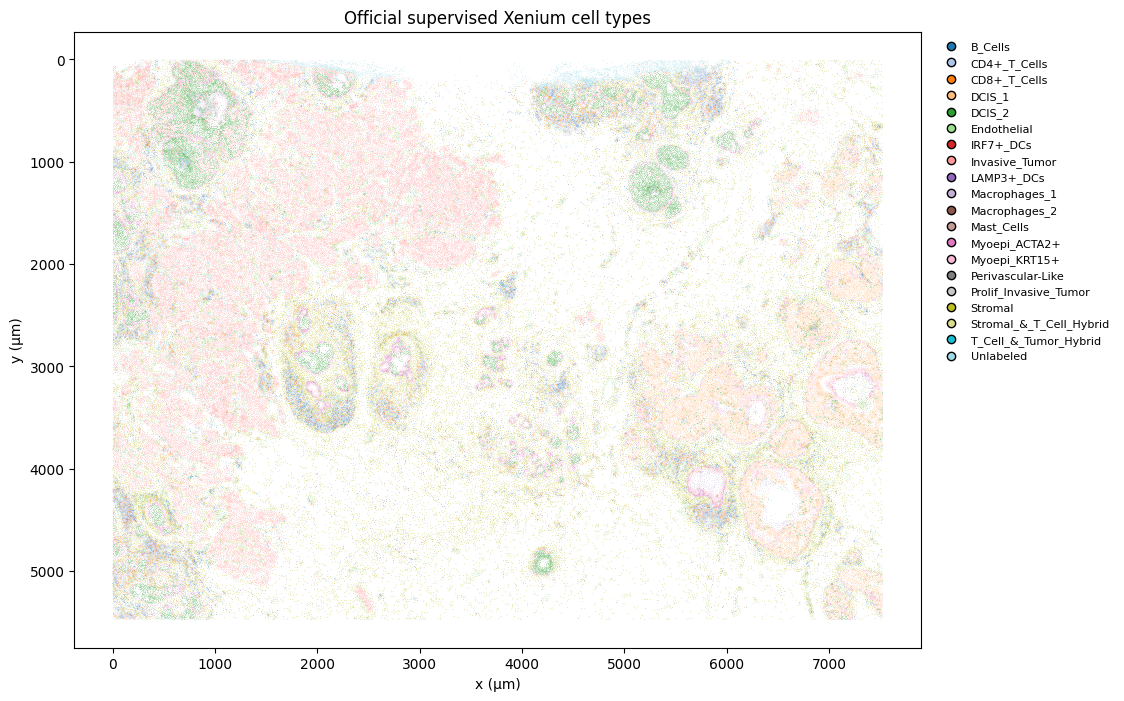

In [4]:
type_colors=plt.get_cmap('tab20',T)(np.arange(T))
fig,ax=plt.subplots(figsize=(11,8))
ax.scatter(coordinates[:,0],coordinates[:,1],c=type_colors[cell_type],s=.24,linewidths=0,rasterized=True)
ax.set(xlabel='x (µm)',ylabel='y (µm)',title='Official supervised Xenium cell types')
ax.set_aspect('equal'); ax.invert_yaxis()
handles=[plt.Line2D([0],[0],marker='o',color='none',markerfacecolor=type_colors[i],markersize=6,label=name) for i,name in enumerate(label_categories)]
ax.legend(handles=handles,bbox_to_anchor=(1.01,1),loc='upper left',frameon=False,fontsize=8)
plt.savefig(f'{dirr}cell_type.png', dpi=600, bbox_inches='tight')
plt.show()


## 4. Fixed V1002 neighborhoods and composition

In [5]:
neighborhoods=build_neighborhoods(coordinates,k=N_NEIGHBORS,sigma=SIGMA_UM)
members=neighborhoods.indices.reshape(N,N_NEIGHBORS)
anchor_weights=neighborhoods.weights.reshape(N,N_NEIGHBORS).astype(np.float32)
BATCH=256
C,_,opportunity=aggregate_pairwise_ccc(
    coordinates,cell_type,np.zeros((N,1),dtype=np.float32),np.zeros((N,1),dtype=np.float32),
    T,sigma=SIGMA_UM,members=members,anchor_weights=anchor_weights,
    batch_size=BATCH,device=DEVICE,compute_signal=False,
)
pair_support=(opportunity>0).sum(0)
assert np.allclose(C.sum(1),1,atol=1e-5)


## 5. Measurable LR atlas and outcome-blind CCC mask

In [6]:
atlas=load_lr_atlas(str(SOURCE.parent/'data/commuspace_human_lr_atlas.tsv'))
panel=set(adata.var_names.str.upper())
measurable=tuple(row for row in atlas.interactions if all(g in panel for g in row.ligand_components+row.receptor_components))
measurable_atlas=LRAtlas(measurable,{'n_raw_lr':len(atlas),'n_unique_lr':len(measurable)},atlas.source_path)
if not measurable: raise RuntimeError('No fully measurable LR interaction in the Xenium panel')
lr_genes=tuple(sorted({g for row in measurable for g in row.ligand_components+row.receptor_components}))
expression=np.column_stack([adata[:,gene].X.toarray().ravel() for gene in lr_genes]).astype(np.float32)
ligand,receptor=_side_expression(expression,lr_genes,measurable_atlas)
coverage_l=np.stack([(ligand[cell_type==t]>0).mean(0) for t in range(T)])
coverage_r=np.stack([(receptor[cell_type==t]>0).mean(0) for t in range(T)])
coverage=((coverage_l[:,None,:]>=.10)&(coverage_r[None,:,:]>=.10)).reshape(T*T,-1)
supported=pair_support>=max(20,int(np.ceil(.01*N)))
feature_mask=(coverage&supported[:,None]).reshape(-1)
final_ccc=int(feature_mask.sum())
display(pd.DataFrame([{'Panel genes':adata.n_vars,'Atlas LR pairs':len(atlas),
                       'Fully measurable LR pairs':len(measurable),'Final directed CCC features':final_ccc}]))
if len(measurable)<100:
    display(Markdown('**WARNING:** Xenium 313-gene panel provides limited LR coverage; the following niche result is exploratory.'))
if final_ccc==0: raise RuntimeError('No directed CCC feature passed the fixed outcome-blind filter')


,Panel genes,Atlas LR pairs,Fully measurable LR pairs,Final directed CCC features
0,313,8408,40,3344


**WARNING:** Xenium 313-gene panel provides limited LR coverage; the following niche result is exploratory.

## 6. Chunked directed CCC from the same neighborhoods

In [7]:
I=np.empty((N,final_ccc),dtype=np.float32)
_,I,signal_opportunity=aggregate_pairwise_ccc(
    coordinates,cell_type,ligand,receptor,T,sigma=SIGMA_UM,
    members=members,anchor_weights=anchor_weights,feature_mask=feature_mask,
    batch_size=BATCH,device=DEVICE,communication_out=I,
)
assert np.allclose(opportunity,signal_opportunity,rtol=1e-5,atol=1e-6)
del signal_opportunity
assert I.shape==(N,final_ccc) and np.isfinite(I).all()


## 7. V1002 flat C+I factorization, K=8

In [8]:
fit=fit_balanced({'HC':C,'HI':I},seed=SEED,iterations=500,device=DEVICE,niches=K_NICHE)
W=np.maximum(fit.W.numpy(),0)
W=W/np.maximum(W.sum(1,keepdims=True),1e-12)
niche=W.argmax(1)
assert W.shape==(N,K_NICHE)


## 8. Matched spatial maps

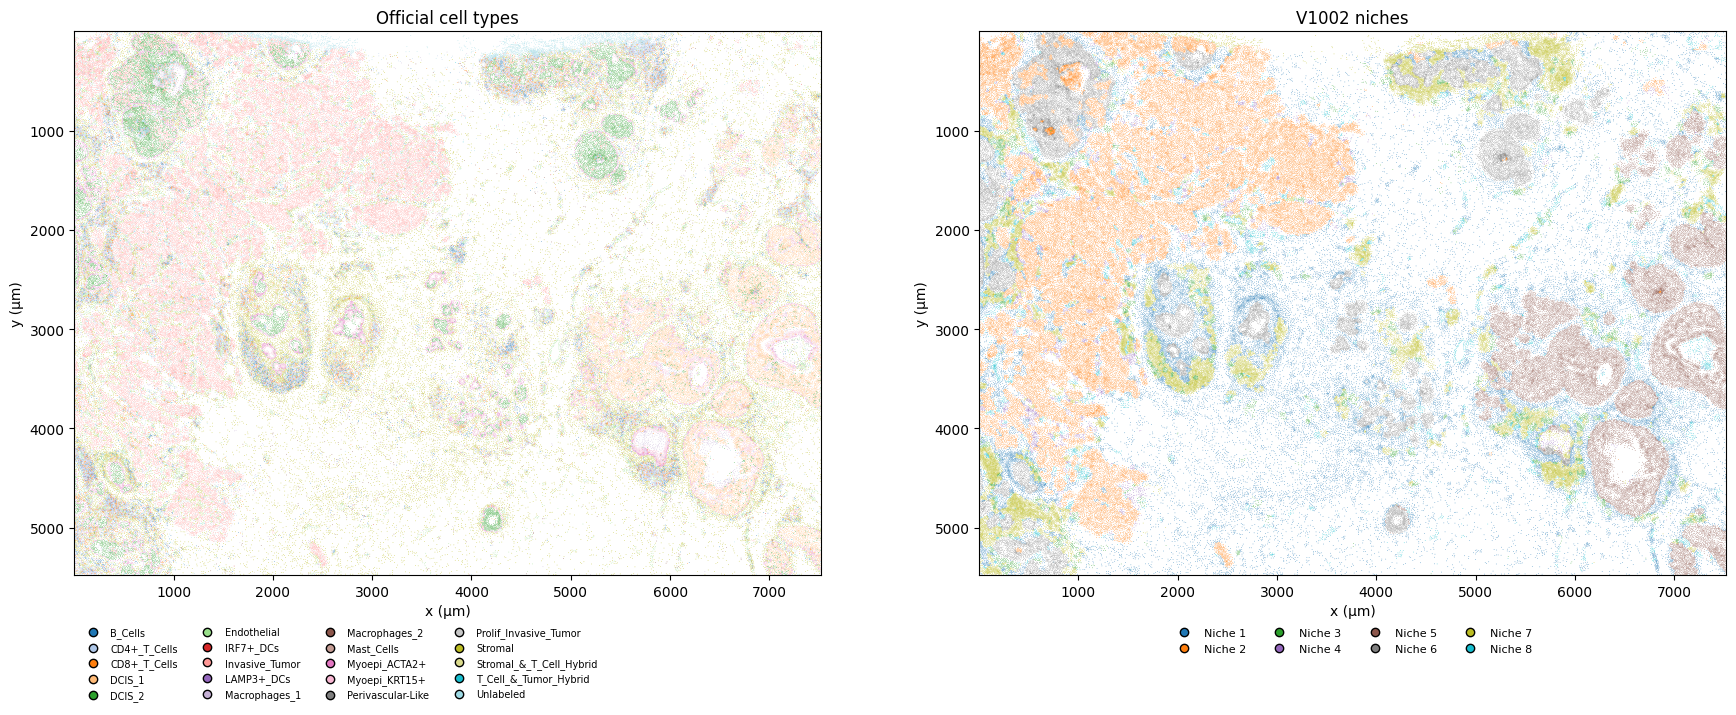

In [9]:
niche_colors=plt.get_cmap('tab10',K_NICHE)(np.arange(K_NICHE))
fig,axes=plt.subplots(1,2,figsize=(18,7),constrained_layout=True)
for ax,colors,title in [(axes[0],type_colors[cell_type],'Official cell types'),
                        (axes[1],niche_colors[niche],'V1002 niches')]:
    ax.scatter(coordinates[:,0],coordinates[:,1],c=colors,s=.24,linewidths=0,rasterized=True)
    ax.set(xlabel='x (µm)',ylabel='y (µm)',title=title)
    ax.set_xlim(coordinates[:,0].min(),coordinates[:,0].max())
    ax.set_ylim(coordinates[:,1].max(),coordinates[:,1].min())
    ax.set_aspect('equal')
axes[0].legend(handles=handles,bbox_to_anchor=(.0,-.08),loc='upper left',ncol=4,frameon=False,fontsize=7)
niche_handles=[plt.Line2D([0],[0],marker='o',color='none',markerfacecolor=niche_colors[k],markersize=6,label=f'Niche {k+1}') for k in range(K_NICHE)]
axes[1].legend(handles=niche_handles,bbox_to_anchor=(.5,-.08),loc='upper center',ncol=4,frameon=False,fontsize=8)
plt.show()


## 9. Small composition summary

In [10]:
background=np.maximum(C.mean(0),1e-8)
rows=[]
for k in range(K_NICHE):
    selected=niche==k; count=int(selected.sum())
    enriched=[] if count==0 else [label_categories[j] for j in np.argsort(-(C[selected].mean(0)/background))[:3]]
    rows.append({'Niche':f'Niche {k+1}','n_cells':count,'fraction':count/N,'top 3 enriched cell types':', '.join(enriched)})
display(pd.DataFrame(rows).round({'fraction':3}))


,Niche,n_cells,fraction,top 3 enriched cell types
0,Niche 1,36942,0.222,"Stromal, Mast_Cells, Macrophages_2"
1,Niche 2,45518,0.274,"Prolif_Invasive_Tumor, Invasive_Tumor, T_Cell_..."
2,Niche 3,6328,0.038,"Macrophages_2, B_Cells, IRF7+_DCs"
3,Niche 4,3157,0.019,"T_Cell_&_Tumor_Hybrid, Macrophages_1, Prolif_I..."
4,Niche 5,21740,0.131,"DCIS_1, Myoepi_KRT15+, Myoepi_ACTA2+"
5,Niche 6,20314,0.122,"DCIS_2, Myoepi_ACTA2+, Myoepi_KRT15+"
6,Niche 7,25994,0.156,"LAMP3+_DCs, CD4+_T_Cells, IRF7+_DCs"
7,Niche 8,6370,0.038,"Perivascular-Like, Endothelial, Macrophages_2"


# 真实数据多视图贡献验证

本节不使用人工区域标签训练模型。组成视图、CCC 视图与已有 Full V1002 使用同一 K、随机种子及优化设置。单视图 niche 编号仅在训练后对齐到 Full，以便比较空间图；官方 cell type 只用于描述性诊断。这里检查组成和通讯各自解释的空间结构，以及 Full 是否在单视图之上区分局部生态状态。

## 固定参数的两个单视图消融

In [11]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import jensenshannon
from scipy import sparse
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from itertools import combinations
assert K_NICHE==8 and W.shape==(N,K_NICHE) and I.shape[0]==N
assert fit.W.shape[1]==K_NICHE
ablation={}
for method,blocks in [('Composition only',{'HC':C}),('CCC only',{'HI':I})]:
    result=fit_balanced(blocks,seed=SEED,iterations=500,device=DEVICE,niches=K_NICHE)
    activity=np.maximum(result.W.numpy(),0)
    activity/=np.maximum(activity.sum(1,keepdims=True),1e-12)
    raw=activity.argmax(1)
    overlap=np.bincount(raw*K_NICHE+niche,minlength=K_NICHE*K_NICHE).reshape(K_NICHE,K_NICHE)
    source_ids,full_ids=linear_sum_assignment(-overlap)
    mapping=np.empty(K_NICHE,dtype=np.int64);mapping[source_ids]=full_ids
    ablation[method]={'raw':raw,'aligned':mapping[raw]}
composition_niche=ablation['Composition only']['aligned']
ccc_niche=ablation['CCC only']['aligned']


## 1×4 空间消融图

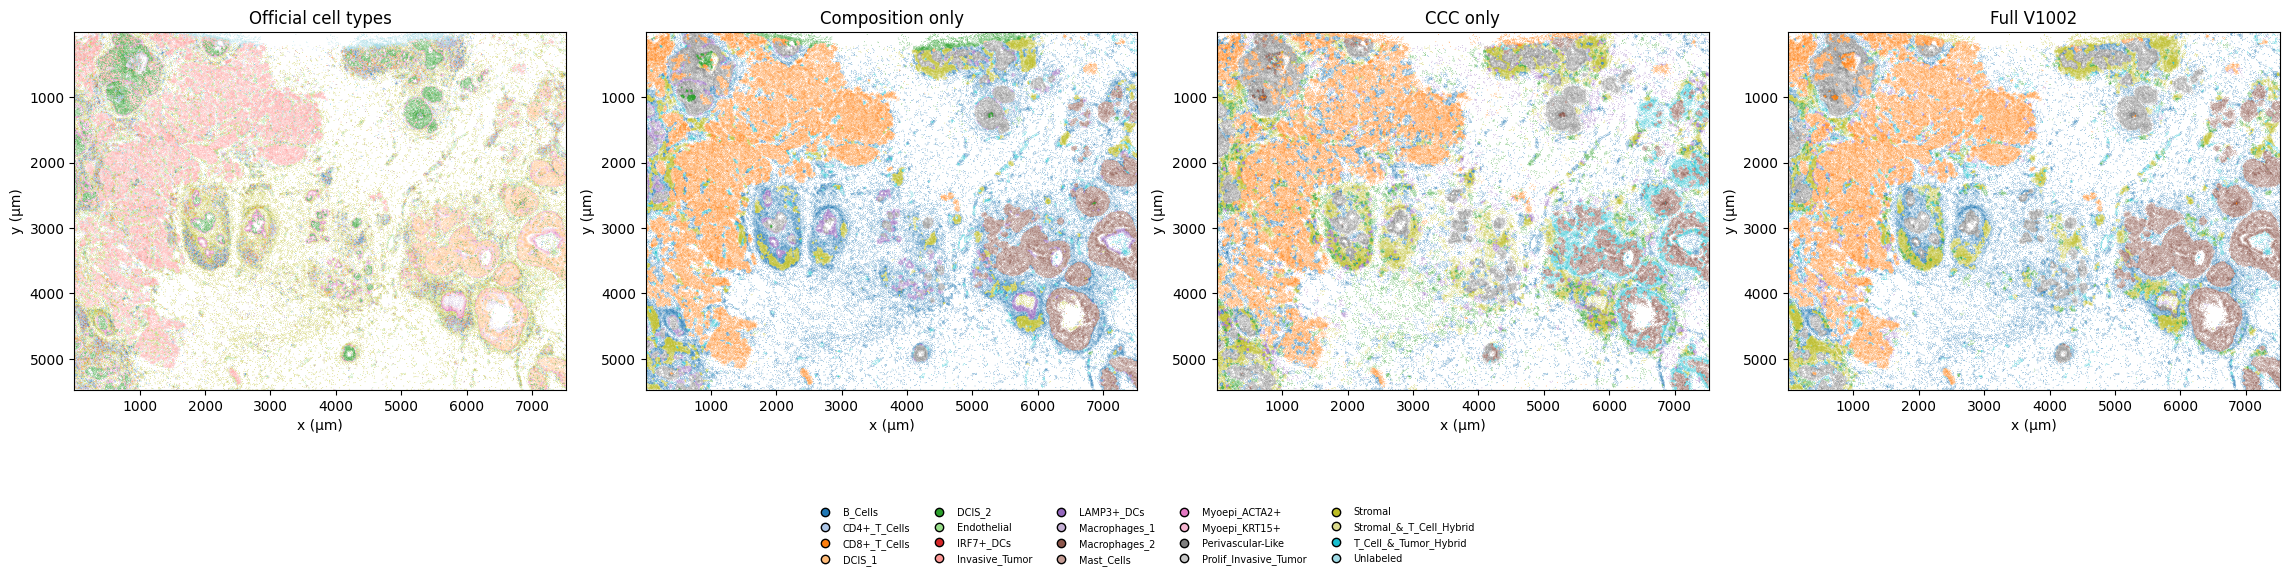

In [12]:
fig,axes=plt.subplots(1,4,figsize=(23,5.5))
spatial_panels=[('Official cell types',type_colors[cell_type]),
                ('Composition only',niche_colors[composition_niche]),
                ('CCC only',niche_colors[ccc_niche]),
                ('Full V1002',niche_colors[niche])]
xlim=(coordinates[:,0].min(),coordinates[:,0].max())
ylim=(coordinates[:,1].max(),coordinates[:,1].min())
for ax,(title,colors) in zip(axes,spatial_panels):
    ax.scatter(coordinates[:,0],coordinates[:,1],c=colors,s=.24,linewidths=0,rasterized=True)
    ax.set(title=title,xlabel='x (µm)',ylabel='y (µm)')
    ax.set_xlim(*xlim);ax.set_ylim(*ylim);ax.set_aspect('equal')
fig.legend(handles=handles,loc='lower center',bbox_to_anchor=(.5,-.12),ncol=5,frameon=False,fontsize=7)
plt.tight_layout(rect=(0,.08,1,1))
plt.savefig(f'{dirr}niche.png', dpi=600, bbox_inches='tight')
plt.show()


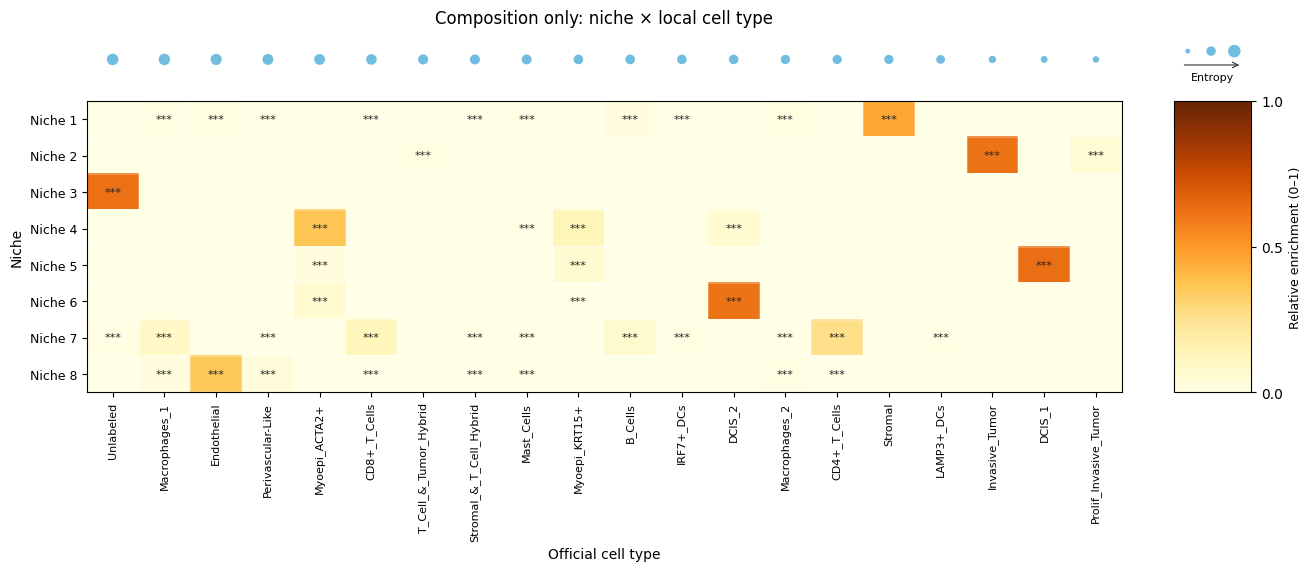

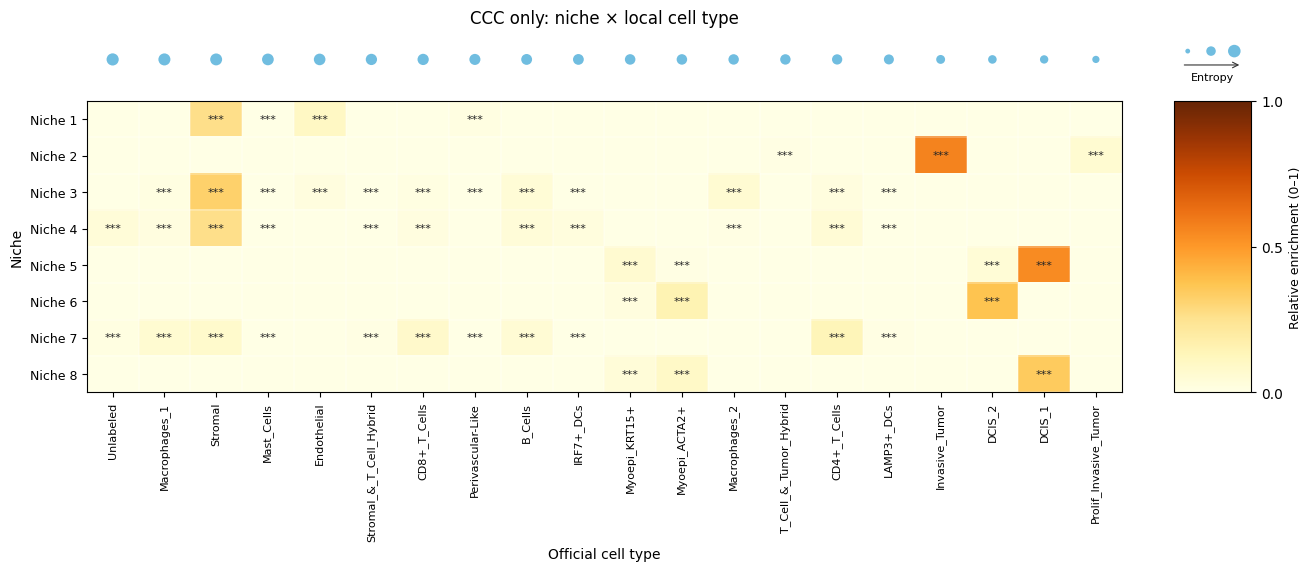

In [16]:
# C-only and I-only niche × cell-type enrichment; Full is intentionally omitted.
from scipy.stats import rankdata, tiecorrect, norm, mannwhitneyu

figure_dir = SOURCE.parent / 'outputs/hbc1_celltype_diagnostics'
figure_dir.mkdir(parents=True, exist_ok=True)
view_labels = {'Composition only': np.asarray(composition_niche),
               'CCC only': np.asarray(ccc_niche)}
assert C.shape == (N, T) and T == len(label_categories)
assert np.allclose(C.sum(axis=1), 1, atol=1e-5)


def draw_niche_enrichment(method, filename):
    labels = view_labels[method]  # Aligned to Full only for label order; assignments are unchanged.
    niches = sorted(np.unique(labels).tolist())
    assert niches == list(range(K_NICHE))
    group = pd.Categorical(labels, categories=niches, ordered=True).codes
    sizes = np.bincount(group, minlength=K_NICHE)
    baseline = C.mean(axis=0)
    means = np.empty((K_NICHE, T), dtype=float)
    pvalues = np.empty((K_NICHE, T), dtype=float)
    for t in range(T):
        values = C[:, t].astype(np.float64)
        ranks = rankdata(values, method='average')
        rank_sum = np.bincount(group, weights=ranks, minlength=K_NICHE)
        abundance = np.bincount(group, weights=values, minlength=K_NICHE)
        means[:, t] = abundance / sizes
        outside = N - sizes
        u = rank_sum - sizes * (sizes + 1) / 2
        sd_u = np.sqrt(sizes * outside * (N + 1) * tiecorrect(ranks) / 12)
        pvalues[:, t] = norm.sf((u - sizes * outside / 2 - .5) / sd_u) if np.all(sd_u > 0) else 1
    # Cross-check one optimized p-value against scipy's one-sided asymptotic U test.
    inside = labels == niches[0]
    expected = mannwhitneyu(C[inside, 0], C[~inside, 0],
                            alternative='greater', method='asymptotic').pvalue
    assert np.isclose(pvalues[0, 0], expected, atol=1e-7)

    enrichment = np.clip((means - baseline[None, :]) /
                         np.maximum(1 - baseline[None, :], 1e-12), 0, 1)
    type_mass = sizes[:, None] * means
    type_share = type_mass / np.maximum(type_mass.sum(axis=0, keepdims=True), 1e-12)
    entropy = -np.sum(np.where(type_share > 0,
                               type_share * np.log(np.maximum(type_share, 1e-300)), 0),
                      axis=0) / np.log(K_NICHE)
    order = np.argsort(-entropy, kind='stable')
    enrichment, pvalues, entropy = enrichment[:, order], pvalues[:, order], entropy[order]
    types_sorted = [label_categories[j] for j in order]
    assert np.all(np.diff(entropy) <= 1e-12)

    fig = plt.figure(figsize=(13, 5.6), layout='constrained')
    grid = fig.add_gridspec(2, 2, width_ratios=[20, 1.5],
                            height_ratios=[0.8, 4.2], hspace=0.02, wspace=0.08)
    ax = fig.add_subplot(grid[1, 0])
    top = fig.add_subplot(grid[0, 0], sharex=ax)
    bar_ax = fig.add_subplot(grid[1, 1])
    legend_ax = fig.add_subplot(grid[0, 1])
    image = ax.imshow(enrichment, cmap='YlOrBr', vmin=0, vmax=1,
                      aspect='auto', interpolation='nearest')
    for row, col in np.ndindex(enrichment.shape):
        if enrichment[row, col] <= 0:
            continue
        p = pvalues[row, col]
        stars = '***' if p <= 1e-4 else '**' if p <= 1e-3 else '*' if p <= .05 else ''
        if stars:
            ax.text(col, row, stars, ha='center', va='center', fontsize=8,
                    color='white' if enrichment[row, col] > .65 else '#252525')
    ax.set_xticks(np.arange(T), types_sorted, rotation=90, ha='center', fontsize=8)
    ax.set_yticks(np.arange(K_NICHE), [f'Niche {k + 1}' for k in niches], fontsize=9)
    ax.set(xlabel='Official cell type', ylabel='Niche')
    ax.set_xticks(np.arange(-.5, T, 1), minor=True)
    ax.set_yticks(np.arange(-.5, K_NICHE, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=.35)
    ax.tick_params(which='minor', bottom=False, left=False)
    top.scatter(np.arange(T), np.zeros(T), s=12 + 70 * entropy,
                color='#70bde0', linewidths=0)
    top.set(xlim=(-.5, T - .5), ylim=(-.5, .5))
    top.set_axis_off()
    top.set_title(f'{method}: niche × local cell type', fontsize=12)
    colorbar = fig.colorbar(image, cax=bar_ax)
    colorbar.set_ticks([0, .5, 1])
    colorbar.set_label('Relative enrichment (0–1)', fontsize=9)
    legend_ax.set(xlim=(0, 1), ylim=(0, 1))
    legend_ax.scatter([.18, .48, .78], [.65] * 3,
                      s=[12 + 70 * value for value in (0, .5, 1)],
                      color='#70bde0', linewidths=0)
    legend_ax.annotate('', xy=(.88, .4), xytext=(.1, .4),
                       arrowprops=dict(arrowstyle='->', lw=.8, color='#333333'))
    legend_ax.text(.5, .12, 'Entropy', ha='center', fontsize=8)
    legend_ax.set_axis_off()
    fig.savefig(Path(dirr) / filename, dpi=600, bbox_inches='tight')
    plt.show()

    records = []
    for row, niche in enumerate(niches):
        for rank, original_type in enumerate(order):
            records.append({'method': method, 'niche': int(niche + 1),
                            'cell_type': label_categories[original_type],
                            'n_cells': int(sizes[row]),
                            'mean_local_fraction': float(means[row, original_type]),
                            'global_mean_local_fraction': float(baseline[original_type]),
                            'relative_enrichment_0to1': float(enrichment[row, rank]),
                            'p_greater_raw': float(pvalues[row, rank]),
                            'across_niche_entropy': float(entropy[rank]),
                            'entropy_rank': rank + 1})
    pd.DataFrame(records).to_csv(f"{dirr}{filename.replace('.png', '.csv')}", index=False)


# Per-cell observations are the existing 30-neighbor composition C[:, t].
# One-sided Mann–Whitney U compares cells inside versus outside each niche.
# Stars show raw p: * <= .05, ** <= .001, *** <= .0001; spatial overlap limits independence.
for method, filename in [('Composition only', 'HBC1_V1002_composition_celltype_heatmap.png'),
                         ('CCC only', 'HBC1_V1002_CCC_celltype_heatmap.png')]:
    draw_niche_enrichment(method, filename)


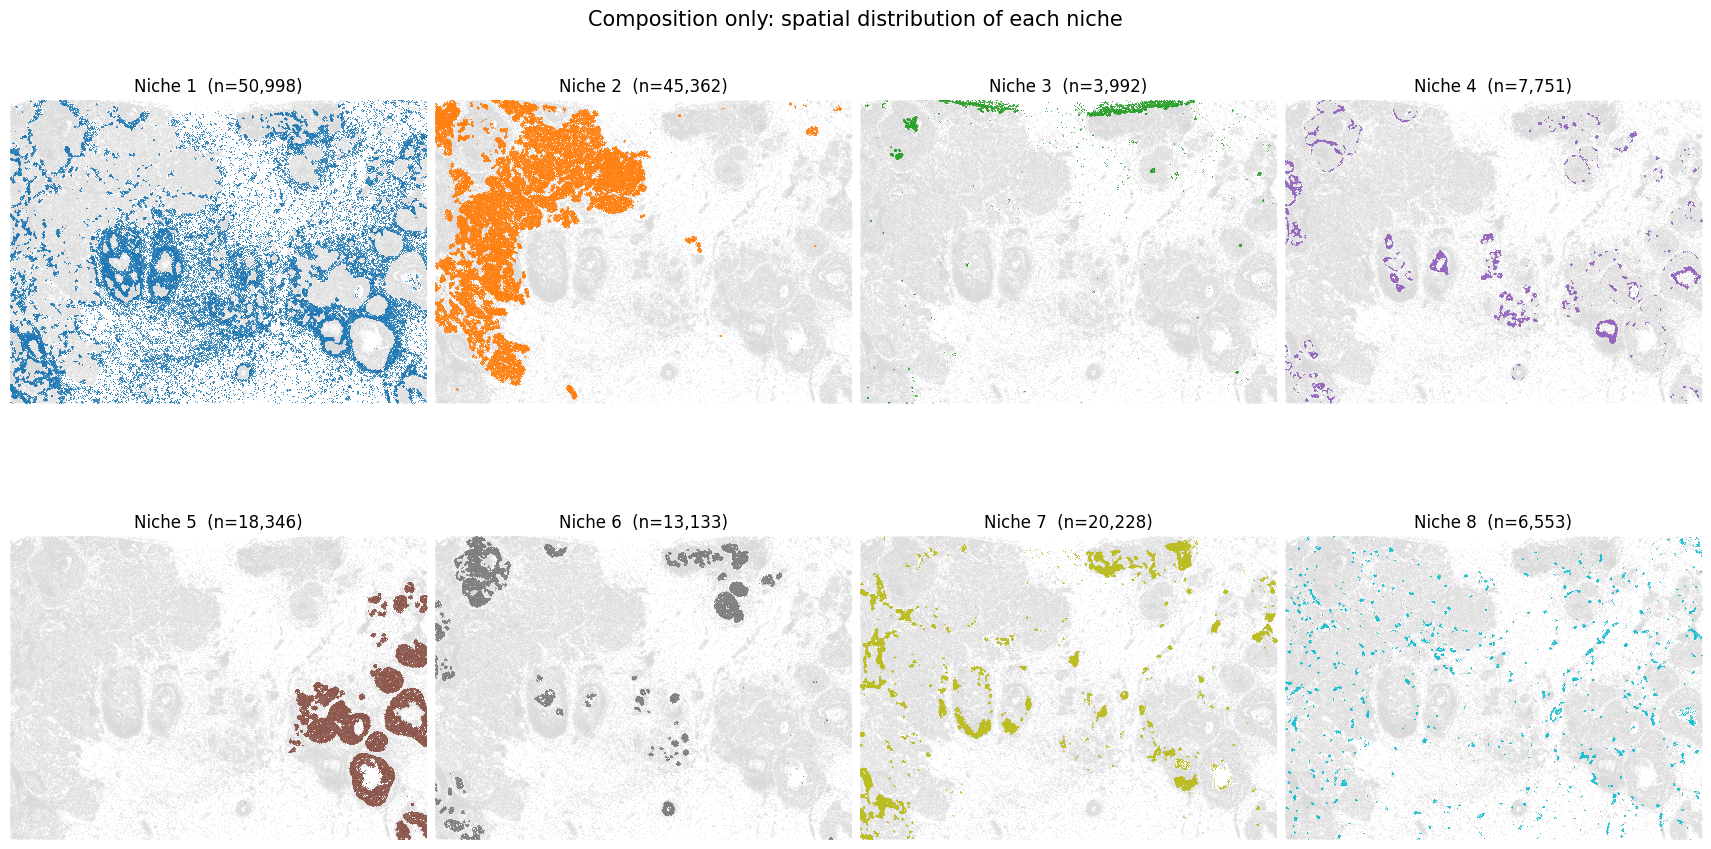

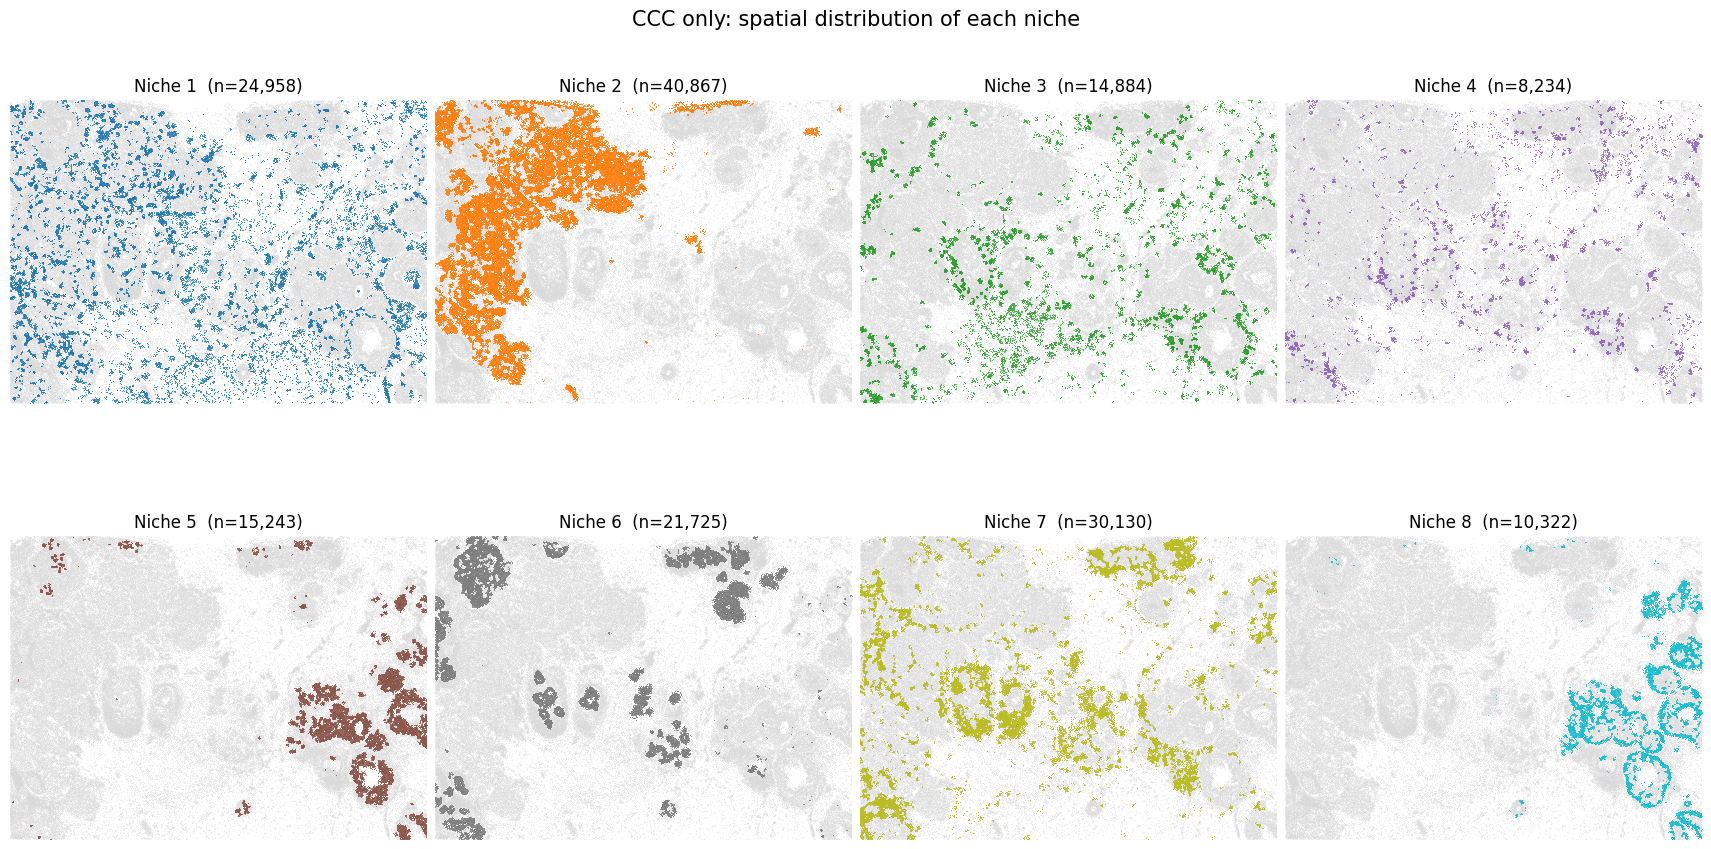

In [ ]:
# C-only and I-only: spatial distribution of every niche in matching 2 × 4 panels.
figure_dir = SOURCE.parent / 'outputs/hbc1_celltype_diagnostics'
figure_dir.mkdir(parents=True, exist_ok=True)
xy = np.asarray(coordinates)
xlim = (xy[:, 0].min(), xy[:, 0].max())
ylim = (xy[:, 1].max(), xy[:, 1].min())  # Match the preceding HBC1 maps.


def draw_each_niche(method, labels, filename):
    labels = np.asarray(labels)
    assert labels.shape == (N,) and set(np.unique(labels)) == set(range(K_NICHE))
    fig, axes = plt.subplots(2, 4, figsize=(17, 9), layout='constrained')
    for niche_id, ax in enumerate(axes.flat):
        selected = labels == niche_id
        ax.scatter(xy[:, 0], xy[:, 1], c='#d9d9d9', s=.16,
                   linewidths=0, rasterized=True)
        ax.scatter(xy[selected, 0], xy[selected, 1], c=[niche_colors[niche_id]],
                   s=.38, linewidths=0, rasterized=True)
        ax.set(xlim=xlim, ylim=ylim,
               title=f'Niche {niche_id + 1}  (n={selected.sum():,})')
        ax.set_aspect('equal')
        ax.set_axis_off()
    fig.suptitle(f'{method}: spatial distribution of each niche', fontsize=15)
    fig.savefig(figure_dir / filename, dpi=220, bbox_inches='tight')
    plt.show()


# The existing Hungarian alignment only permutes labels; no cell assignment changes.
draw_each_niche('Composition only', composition_niche,
                'HBC1_V1002_composition_each_niche.png')
draw_each_niche('CCC only', ccc_niche,
                'HBC1_V1002_CCC_each_niche.png')


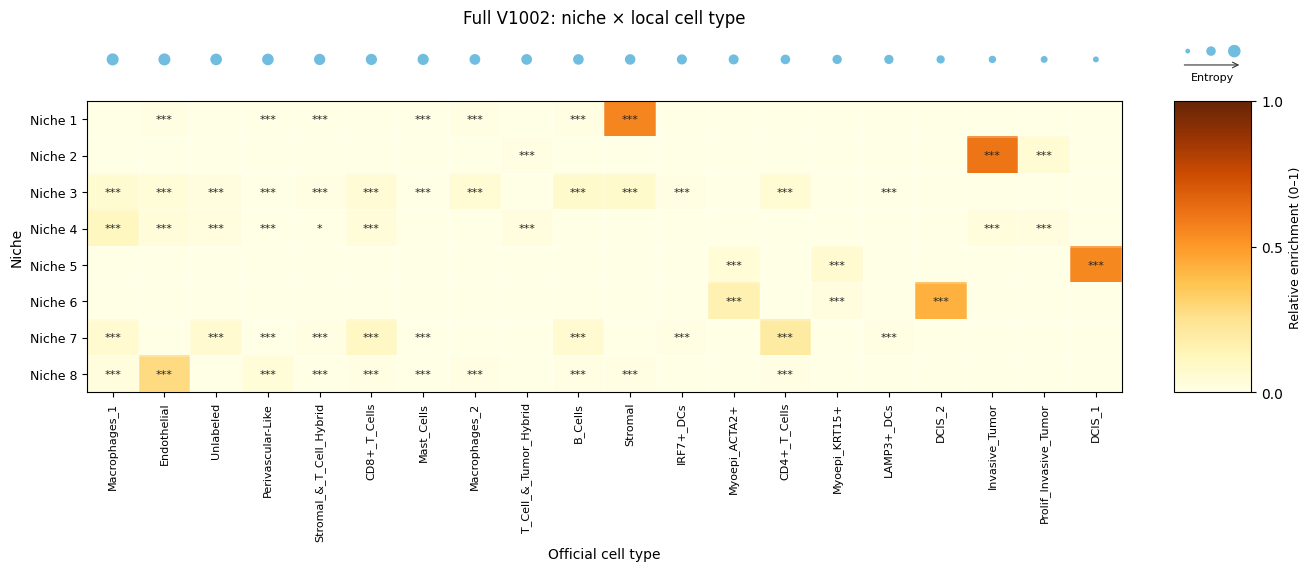

In [17]:
# Full V1002 uses its original niche labels; the heatmap follows the same scale and test.
view_labels['Full V1002'] = np.asarray(niche)
draw_niche_enrichment('Full V1002', 'HBC1_V1002_full_celltype_heatmap.png')


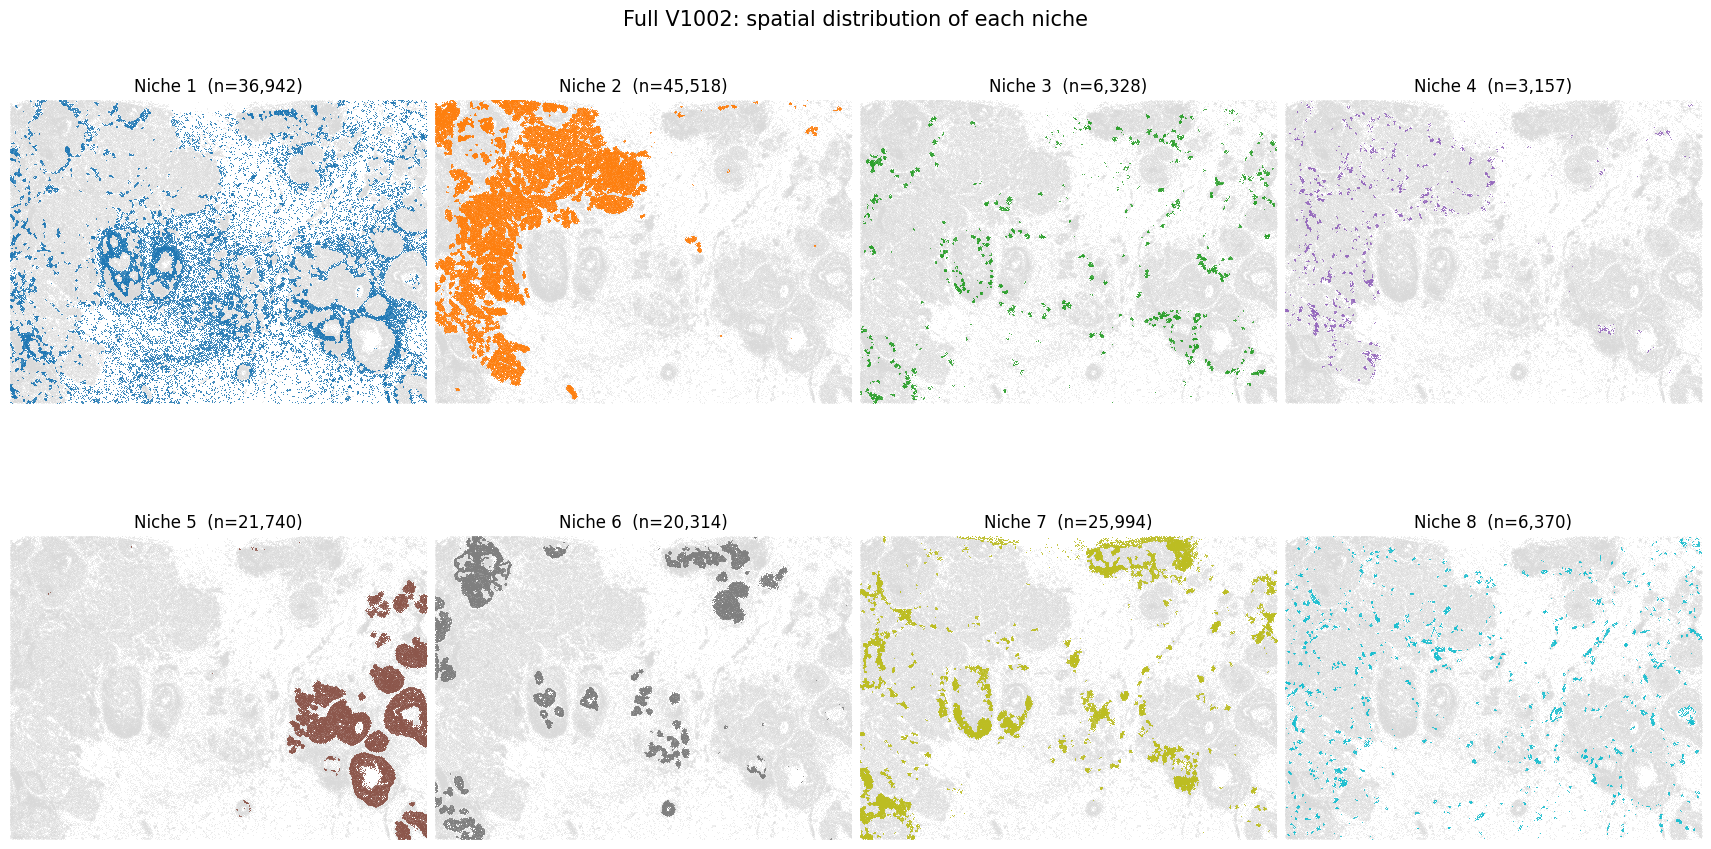

In [18]:
# Full V1002: spatial distribution of each niche in the same 2 × 4 layout.
draw_each_niche('Full V1002', niche, 'HBC1_V1002_full_each_niche.png')


In [19]:
# Top 10 directed CCC features per CCC-only niche (dictionary loadings, not significance).
assert set(result.dictionaries) == {'HI'}, 'The last single-view fit must be CCC-only.'
hi_raw = result.dictionaries['HI'].numpy()
assert hi_raw.shape == (K_NICHE, final_ccc)
raw_labels = ablation['CCC only']['raw']
overlap = np.bincount(raw_labels * K_NICHE + niche,
                      minlength=K_NICHE * K_NICHE).reshape(K_NICHE, K_NICHE)
source_ids, full_ids = linear_sum_assignment(-overlap)
hi_aligned = np.empty_like(hi_raw)
hi_aligned[full_ids] = hi_raw[source_ids]
raw_to_full = np.empty(K_NICHE, dtype=int)
raw_to_full[source_ids] = full_ids
assert np.array_equal(raw_to_full[raw_labels], ccc_niche)

# feature_mask was flattened as sender type × receiver type × measurable LR pair.
selected_flat = np.flatnonzero(feature_mask)
sender_ids, receiver_ids, lr_ids = np.unravel_index(
    selected_flat, (T, T, len(measurable)))
assert len(selected_flat) == hi_aligned.shape[1] == I.shape[1]

TOP_CCC = 10
ccc_rows = []
for niche_id in range(K_NICHE):
    loadings = hi_aligned[niche_id]
    for rank, feature_id in enumerate(np.argsort(-loadings, kind='stable')[:TOP_CCC], 1):
        lr = measurable[lr_ids[feature_id]]
        ccc_rows.append({
            'CCC-only niche': f'Niche {niche_id + 1}',
            'n_cells': int(np.sum(ccc_niche == niche_id)),
            'rank': rank,
            'sender': label_categories[sender_ids[feature_id]],
            'receiver': label_categories[receiver_ids[feature_id]],
            'ligand': lr.ligand,
            'receptor': lr.receptor,
            'LR ID': lr.lr_id,
            'HI loading': float(loadings[feature_id]),
        })
ccc_top = pd.DataFrame(ccc_rows)
ccc_top.to_csv(Path(dirr) / 'HBC1_V1002_CCC_only_top10_CCC.csv', index=False)
with pd.option_context('display.max_rows', K_NICHE * TOP_CCC):
    display(ccc_top)


,CCC-only niche,n_cells,rank,sender,receiver,ligand,receptor,LR ID,HI loading
0,Niche 1,24958,1,Endothelial,Endothelial,PECAM1,PECAM1,CommuSpace_HS_06139,13.551421
1,Niche 1,24958,2,Stromal,Endothelial,MMP2,PECAM1,CommuSpace_HS_05481,8.215135
2,Niche 1,24958,3,Endothelial,Macrophages_1,CXCL12,CD4,CommuSpace_HS_02207,5.641763
3,Niche 1,24958,4,Endothelial,Endothelial,MMRN2,CD93,CommuSpace_HS_05501,5.092506
4,Niche 1,24958,5,Endothelial,Macrophages_1,CXCL12,CXCR4,CommuSpace_HS_02209,4.540204
5,Niche 1,24958,6,Endothelial,Endothelial,MMP2,PECAM1,CommuSpace_HS_05481,4.088513
6,Niche 1,24958,7,Endothelial,Endothelial,MMRN2,CLEC14A,CommuSpace_HS_05502,3.856750
7,Niche 1,24958,8,Stromal,Endothelial,PECAM1,PECAM1,CommuSpace_HS_06139,3.803218
8,Niche 1,24958,9,Endothelial,Stromal,PECAM1,PECAM1,CommuSpace_HS_06139,3.803217
9,Niche 1,24958,10,Endothelial,Stromal,CXCL12,CXCR4,CommuSpace_HS_02209,3.792026
